In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif,SelectKBest, chi2,RFE,SequentialFeatureSelector as SFS
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier


In [2]:
#import data and explore data
df = pd.read_csv("Dataset_Study3.csv")
#df.head()
print("info " , df.info())
print("Desc" ,df.describe())
print("Is null ",df.isnull().value_counts())
print("is duplicate: ",df.duplicated().value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426 entries, 0 to 425
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   HRV_MeanNN      426 non-null    float64
 1   HRV_SDNN        426 non-null    float64
 2   HRV_RMSSD       426 non-null    float64
 3   HRV_Prc20NN     426 non-null    float64
 4   HRV_Prc80NN     426 non-null    float64
 5   HRV_pNN50       426 non-null    float64
 6   HRV_HTI         426 non-null    float64
 7   HRV_VLF         426 non-null    float64
 8   HRV_LF          426 non-null    float64
 9   HRV_HF          426 non-null    float64
 10  HRV_TP          426 non-null    float64
 11  HRV_LFHF        426 non-null    float64
 12  HRV_SD1         426 non-null    float64
 13  HRV_SD2         426 non-null    float64
 14  HRV_SD1SD2      426 non-null    float64
 15  HRV_DFA_alpha1  426 non-null    float64
 16  HRV_DFA_alpha2  426 non-null    float64
 17  HRV_ApEn        426 non-null    flo

In [3]:

y = df['Label']
df.drop('Label',axis =1,inplace =True)

#Standard scaling data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df)
X_scaled = pd.DataFrame(data_scaled,columns=df.columns)


In [4]:
X_scaled.columns

Index(['HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_Prc20NN', 'HRV_Prc80NN',
       'HRV_pNN50', 'HRV_HTI', 'HRV_VLF', 'HRV_LF', 'HRV_HF', 'HRV_TP',
       'HRV_LFHF', 'HRV_SD1', 'HRV_SD2', 'HRV_SD1SD2', 'HRV_DFA_alpha1',
       'HRV_DFA_alpha2', 'HRV_ApEn', 'HRV_SampEn'],
      dtype='object')

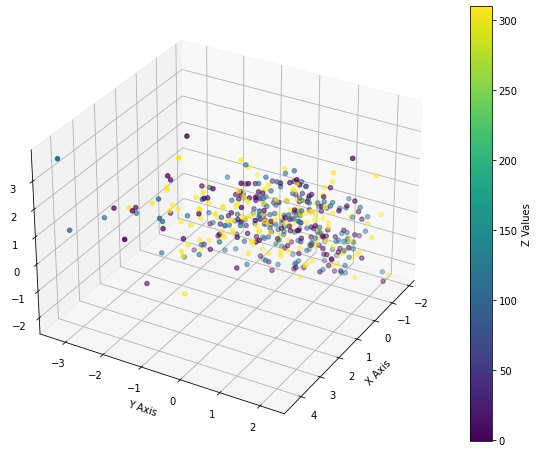

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Generate sample data (replace this with your actual data)
# Create a scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_scaled['HRV_SD1SD2'], X_scaled['HRV_DFA_alpha1'], X_scaled['HRV_MeanNN'], c=y, cmap='viridis')

# Customize plot appearance
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
cbar = fig.colorbar(scatter)
cbar.set_label('Z Values')

# Change the perspective (adjust the viewing angle)
ax.view_init(elev=30, azim=30)

plt.show()


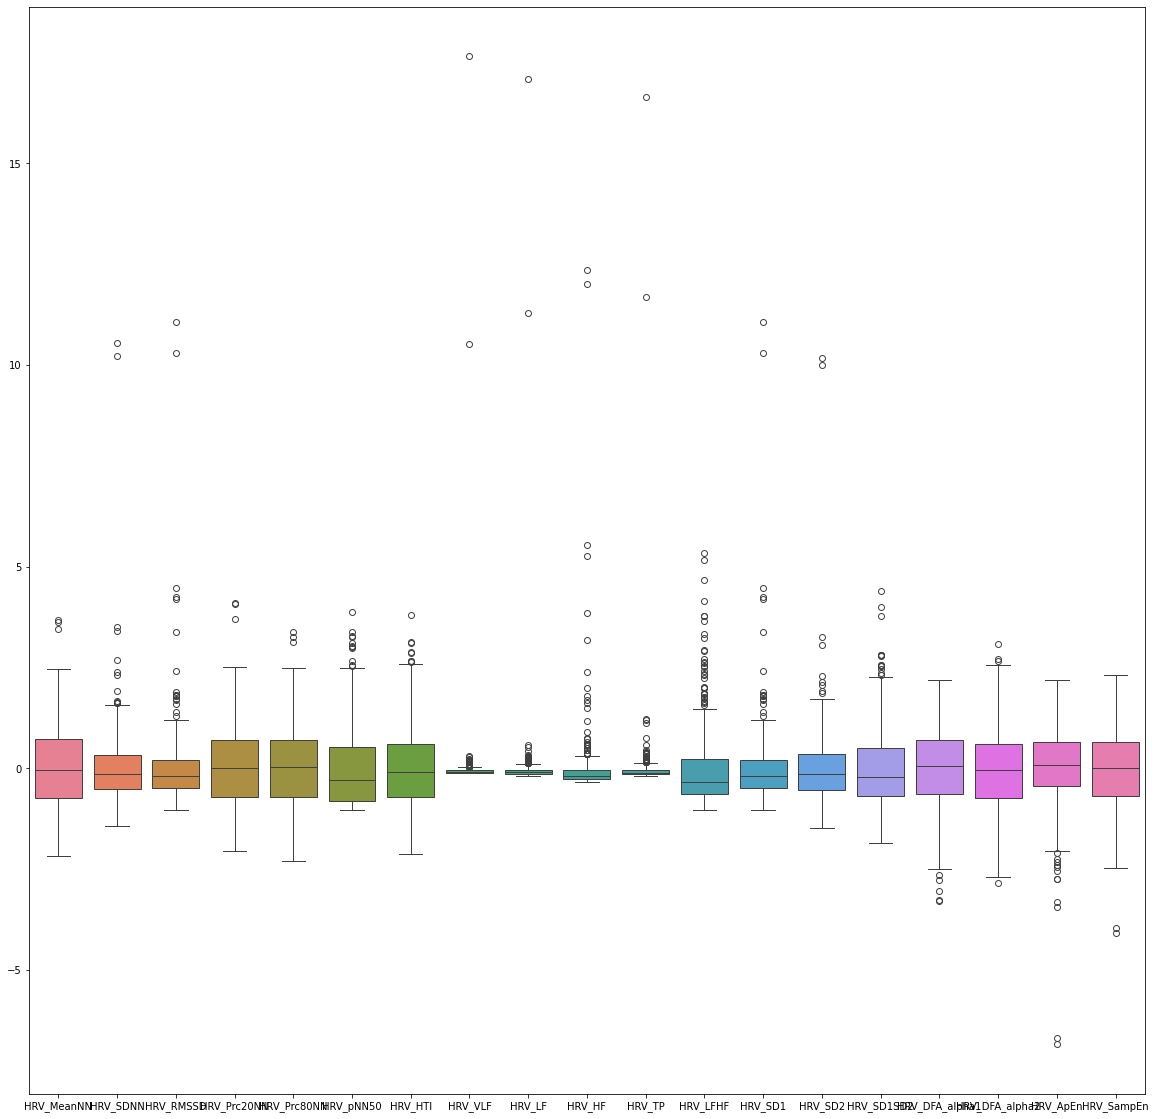

In [6]:
plt.figure(figsize=(20,20))
sns.boxplot(X_scaled)
plt.show()

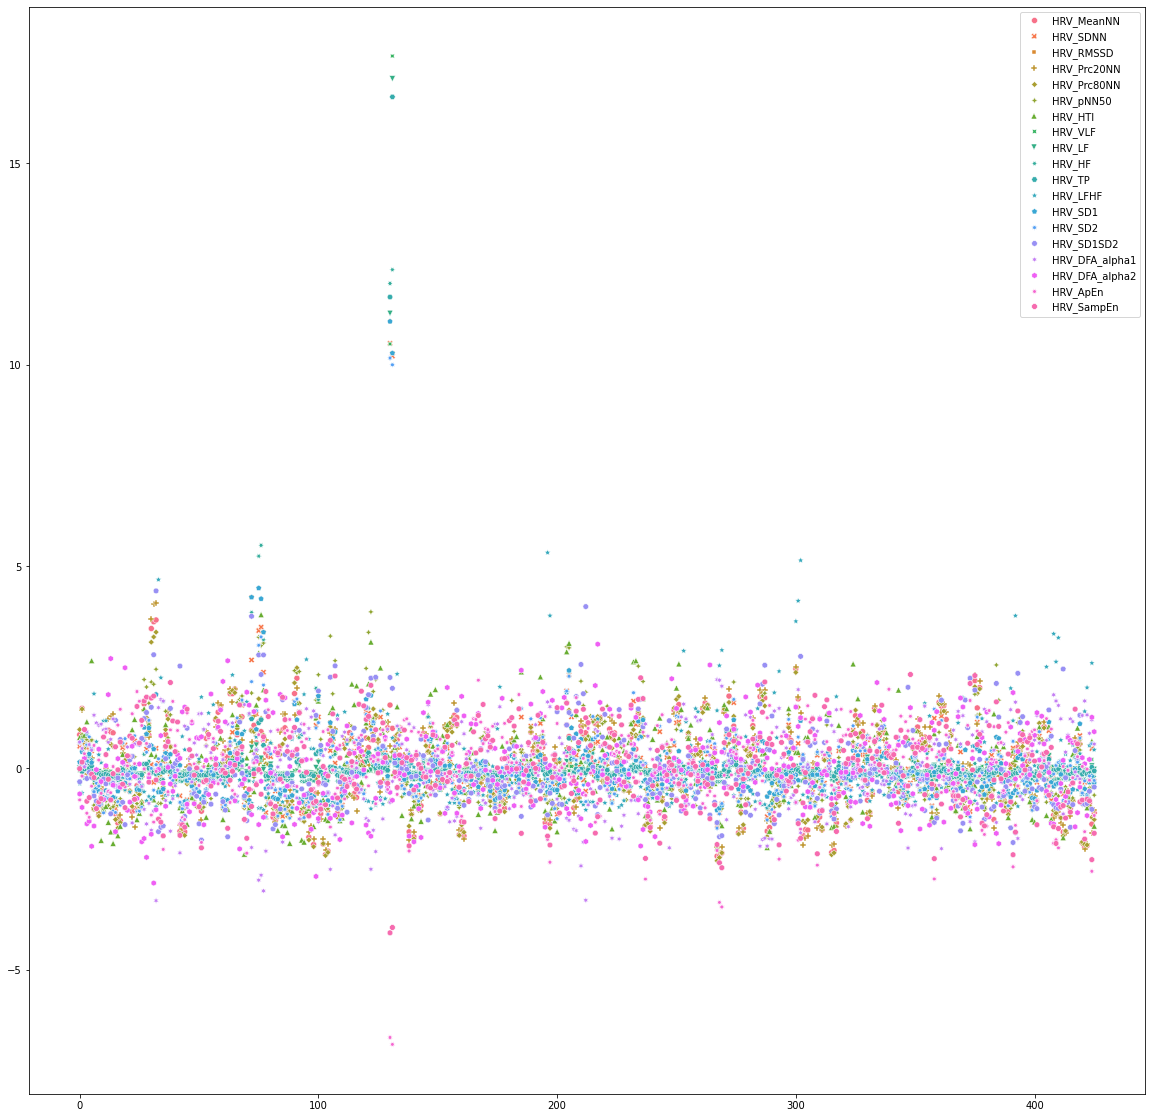

In [7]:
plt.figure(figsize=(20,20))
sns.scatterplot(X_scaled)
plt.show()

Feature Selection

In [8]:
correlation_matrix = X_scaled.corr().abs()
# Create a mask to exclude the upper triangle of the correlation matrix (to avoid duplicates)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
# Identify features with correlation above a certain threshold
threshold = 0.8
correlated_features = [column for column in range(len(correlation_matrix.columns)) if any(correlation_matrix.iloc[:column, column] > threshold)]
# Drop the highly correlated features
# droping correlated(similar features allows to simplify the data for the model of classification)
selected_features = X_scaled.drop(columns=X_scaled.columns[correlated_features])
print(selected_features.columns)


Index(['HRV_MeanNN', 'HRV_SDNN', 'HRV_pNN50', 'HRV_HTI', 'HRV_VLF', 'HRV_LFHF',
       'HRV_SD1SD2', 'HRV_DFA_alpha2', 'HRV_ApEn', 'HRV_SampEn'],
      dtype='object')


In [9]:
#mutual info gain
# Calculate information gain for each feature
info_gain = mutual_info_classif(X_scaled, y)
# Create a DataFrame to display feature names and their information gain
feature_info_gain = pd.DataFrame({'Feature': X_scaled.columns, 'Info Gain': info_gain})
top = feature_info_gain.sort_values(by='Info Gain', ascending=False,inplace=False)
top = top.head(10)
# Print or use the selected features based on information gain
print("Feature Information Gain:")
print(list(top['Feature']))

Feature Information Gain:
['HRV_SD1SD2', 'HRV_DFA_alpha1', 'HRV_MeanNN', 'HRV_ApEn', 'HRV_Prc20NN', 'HRV_Prc80NN', 'HRV_HF', 'HRV_VLF', 'HRV_LF', 'HRV_SDNN']


In [10]:
# selct k best w.r.t chi-score
k_best =  SelectKBest(chi2, k=10)  # Set 'k' to the desired number of features
X_train_chi2 = k_best.fit_transform(X_scaled, y)
X_test_chi2 = k_best.transform(X_scaled)
# Get the selected feature indices
selected_feature_indices = k_best.get_support(indices=True)
# Get the names of the selected features
selected_feature_names_chi = X_scaled.feature_names[selected_feature_indices]
# Print or use the selected features
print("Selected Features based on Chi-squared:")
print(selected_feature_names_chi)

ValueError: Input X must be non-negative.

In [ ]:
#recursive feature elimination based on logistic regression
model = LogisticRegression()
rfe = RFE(model, n_features_to_select=10) # Selecting top 5 features
fit = rfe.fit(X_scaled, y)
# Print the selected features
selected_features2 = [f for f, s in zip(df.columns, fit.support_) if s]
print("Selected Features: ", selected_features2)


Selected Features:  ['HRV_RMSSD', 'HRV_VLF', 'HRV_LF', 'HRV_HF', 'HRV_TP', 'HRV_SD1', 'HRV_SD1SD2', 'HRV_DFA_alpha1', 'HRV_ApEn', 'HRV_SampEn']


In [ ]:
# Forward Selection using SFS from sklearn
sfs_forward = SFS(estimator=model,n_features_to_select=10,direction='forward',scoring='accuracy',cv=5)
sfs_forward = sfs_forward.fit(X_scaled, y)
cols = df.columns[sfs_forward.get_support()==True]
print(cols)

Index(['HRV_MeanNN', 'HRV_Prc20NN', 'HRV_Prc80NN', 'HRV_VLF', 'HRV_LF',
       'HRV_HF', 'HRV_TP', 'HRV_LFHF', 'HRV_SD1SD2', 'HRV_DFA_alpha2'],
      dtype='object')


In [ ]:
sfs_backward = SFS(estimator=model,n_features_to_select=10, direction='backward',scoring='accuracy',cv=5)
sfs_backward = sfs_backward.fit(X_scaled, y)
cols_b = df.columns[sfs_backward.get_support()==True]
cols_b


Index(['HRV_MeanNN', 'HRV_Prc20NN', 'HRV_HTI', 'HRV_VLF', 'HRV_LF', 'HRV_HF',
       'HRV_LFHF', 'HRV_SD1', 'HRV_SD2', 'HRV_DFA_alpha2'],
      dtype='object')

In [ ]:
# RandomForestClassifier for feature importance
rf_model = RandomForestClassifier()
rf_model.fit(X_scaled, y)
# Extracting feature importances
rf_importances = rf_model.feature_importances_
rf_indices = np.argsort(rf_importances)[::-1]
top_features_rf = X_scaled.columns[rf_indices[:10]]
print(top_features_rf)

Index(['HRV_DFA_alpha2', 'HRV_VLF', 'HRV_SampEn', 'HRV_DFA_alpha1',
       'HRV_SD1SD2', 'HRV_LFHF', 'HRV_ApEn', 'HRV_HTI', 'HRV_LF', 'HRV_HF'],
      dtype='object')


In [ ]:

# DecisionTreeClassifier for feature importance
dtree_model = DecisionTreeClassifier(random_state=0)
dtree_model.fit(X_scaled, y)
# Extracting feature importances
dtree_importances = dtree_model.feature_importances_
dtree_indices = np.argsort(dtree_importances)[::-1]
top_features_dtree = X_scaled.columns[dtree_indices[:10]]
print(top_features_dtree)



Index(['HRV_DFA_alpha2', 'HRV_LF', 'HRV_HTI', 'HRV_LFHF', 'HRV_Prc20NN',
       'HRV_DFA_alpha1', 'HRV_VLF', 'HRV_SampEn', 'HRV_SD1SD2', 'HRV_HF'],
      dtype='object')


In [ ]:
#pCA
pca = PCA(n_components=10)  # Set the number of components you want
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train_pca = pca.fit_transform(X_scaled)
X_test_pca = pca.transform(X_test)
print("Explained Variance Ratio:")
print(pca.feature_names_in_)


Explained Variance Ratio:
['HRV_MeanNN' 'HRV_SDNN' 'HRV_RMSSD' 'HRV_Prc20NN' 'HRV_Prc80NN'
 'HRV_pNN50' 'HRV_HTI' 'HRV_VLF' 'HRV_LF' 'HRV_HF' 'HRV_TP' 'HRV_LFHF'
 'HRV_SD1' 'HRV_SD2' 'HRV_SD1SD2' 'HRV_DFA_alpha1' 'HRV_DFA_alpha2'
 'HRV_ApEn' 'HRV_SampEn']


In [ ]:
l = ['HRV_MeanNN', 'HRV_SDNN', 'HRV_pNN50', 'HRV_HTI', 'HRV_VLF', 'HRV_LFHF',
'HRV_SD1SD2', 'HRV_DFA_alpha2', 'HRV_ApEn', 'HRV_SampEn','HRV_SD1SD2', 
'HRV_DFA_alpha1', 'HRV_MeanNN', 'HRV_ApEn', 'HRV_HTI', 'HRV_HF', 'HRV_pNN50', 
'HRV_VLF', 'HRV_LF', 'HRV_SDNN','HRV_RMSSD', 'HRV_VLF', 'HRV_LF', 'HRV_HF', 
'HRV_TP', 'HRV_SD1', 'HRV_SD1SD2', 'HRV_DFA_alpha1', 'HRV_ApEn', 'HRV_SampEn',
'HRV_MeanNN', 'HRV_Prc20NN', 'HRV_Prc80NN', 'HRV_VLF', 'HRV_LF','HRV_HF', 
'HRV_TP', 'HRV_LFHF', 'HRV_SD1SD2', 'HRV_DFA_alpha2','HRV_MeanNN', 'HRV_Prc20NN', 
'HRV_HTI', 'HRV_VLF', 'HRV_LF', 'HRV_HF','HRV_LFHF', 'HRV_SD1', 'HRV_SD2', 'HRV_DFA_alpha2','HRV_DFA_alpha2', 'HRV_VLF', 'HRV_SampEn', 'HRV_DFA_alpha1',
       'HRV_SD1SD2', 'HRV_LFHF', 'HRV_ApEn', 'HRV_HTI', 'HRV_LF', 'HRV_HF','HRV_DFA_alpha2', 'HRV_LF', 'HRV_HTI', 'HRV_LFHF', 'HRV_Prc20NN',
       'HRV_DFA_alpha1', 'HRV_VLF', 'HRV_SampEn', 'HRV_SD1SD2', 'HRV_HF','HRV_MeanNN' 'HRV_SDNN' 'HRV_RMSSD' 'HRV_Prc20NN' 'HRV_Prc80NN'
 'HRV_pNN50' 'HRV_HTI' 'HRV_VLF' 'HRV_LF' 'HRV_HF' 'HRV_TP' 'HRV_LFHF'
 'HRV_SD1' 'HRV_SD2' 'HRV_SD1SD2' 'HRV_DFA_alpha1' 'HRV_DFA_alpha2'
 'HRV_ApEn' 'HRV_SampEn']

In [ ]:
from collections import Counter# Count occurrences
occurrences = Counter(l)
# Print the result
for element, count in sorted(occurrences.items(), key=lambda x: x[1], reverse=True):
    print(f"{element}: {count} times")
    

HRV_VLF: 7 times
HRV_SD1SD2: 6 times
HRV_HF: 6 times
HRV_LF: 6 times
HRV_HTI: 5 times
HRV_LFHF: 5 times
HRV_DFA_alpha2: 5 times
HRV_MeanNN: 4 times
HRV_ApEn: 4 times
HRV_SampEn: 4 times
HRV_DFA_alpha1: 4 times
HRV_Prc20NN: 3 times
HRV_SDNN: 2 times
HRV_pNN50: 2 times
HRV_TP: 2 times
HRV_SD1: 2 times
HRV_RMSSD: 1 times
HRV_Prc80NN: 1 times
HRV_SD2: 1 times


In [12]:
# create a new df with selected features
sel = ['HRV_VLF','HRV_SD1SD2','HRV_HF','HRV_LF','HRV_HTI','HRV_LFHF','HRV_DFA_alpha2']
sel = ['HRV_DFA_alpha2','HRV_MeanNN','HRV_ApEn','HRV_SampEn','HRV_DFA_alpha1','HRV_Prc20NN','HRV_SDNN']
df_new = pd.concat([X_scaled[sel],y],axis=1)
df_new.head()

,HRV_VLF,HRV_SD1SD2,HRV_HF,HRV_LF,HRV_HTI,HRV_LFHF,HRV_DFA_alpha2,Label
0,-0.057106,-0.337094,0.021977,0.003484,0.762445,-0.385145,-0.638824,-1
1,-0.088044,0.097432,-0.068177,-0.091286,0.768410,-0.615648,-0.972308,310
2,-0.060012,0.067542,-0.048647,-0.002359,0.820605,-0.244458,0.243675,109
3,-0.041903,-0.257033,-0.031120,0.262791,1.150179,0.841994,-1.378825,-1
4,-0.058303,-0.105376,-0.125117,0.038973,0.396521,0.297961,-1.314810,310


In [13]:
y = df_new['Label']
df_new.drop('Label',axis =1,inplace =True)


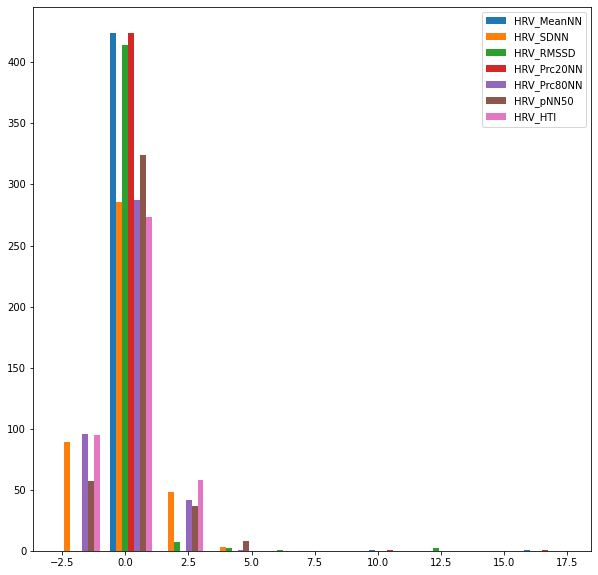

In [ ]:
plt.figure(figsize=(10,10))
plt.hist(df_new)
plt.legend(df.columns)
plt.show()

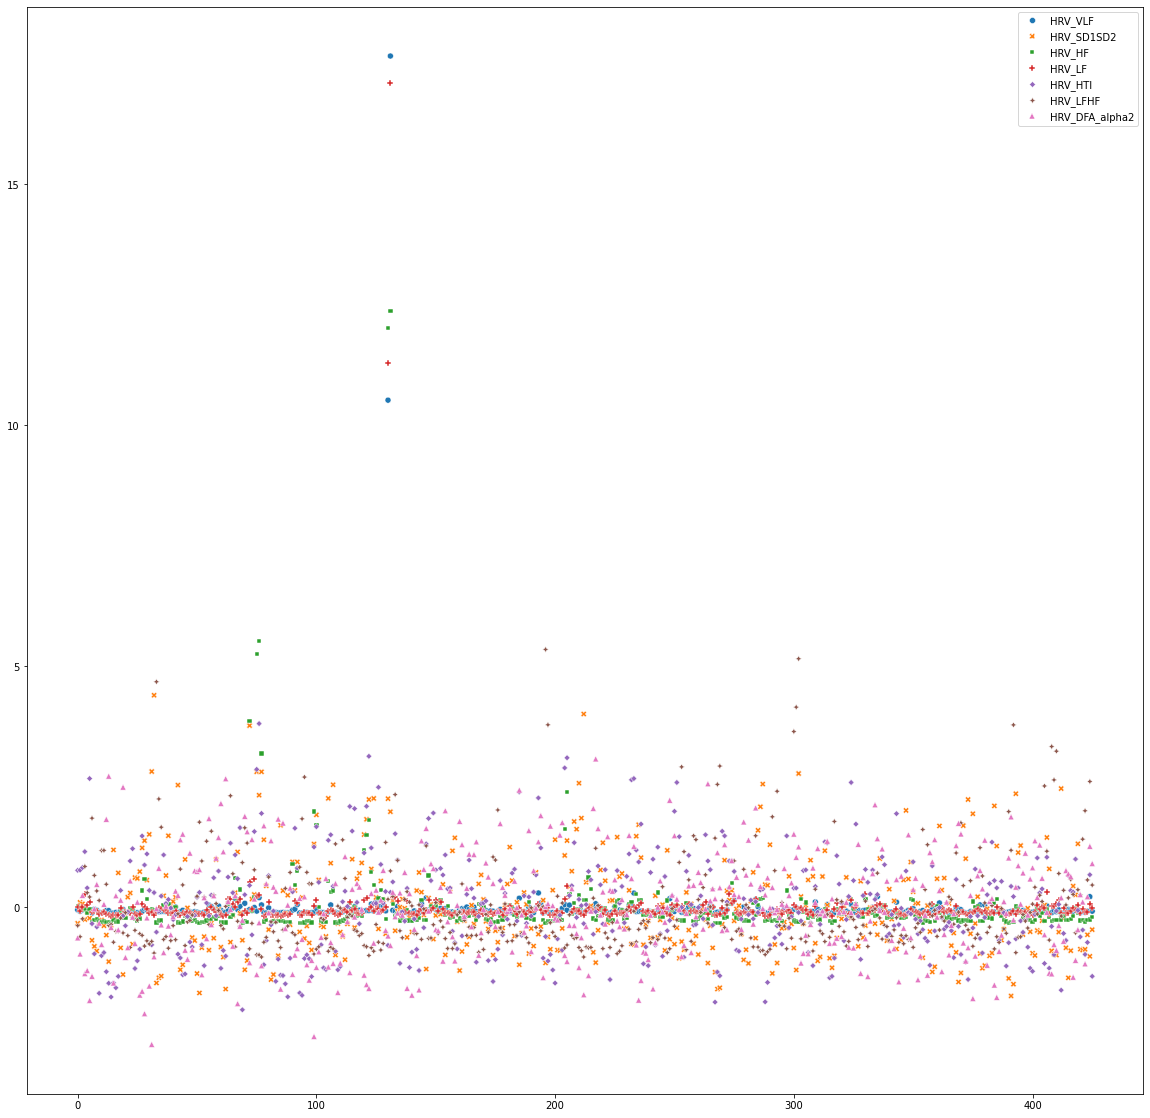

In [ ]:
plt.figure(figsize=(20,20))
sns.scatterplot(df_new)
plt.show()

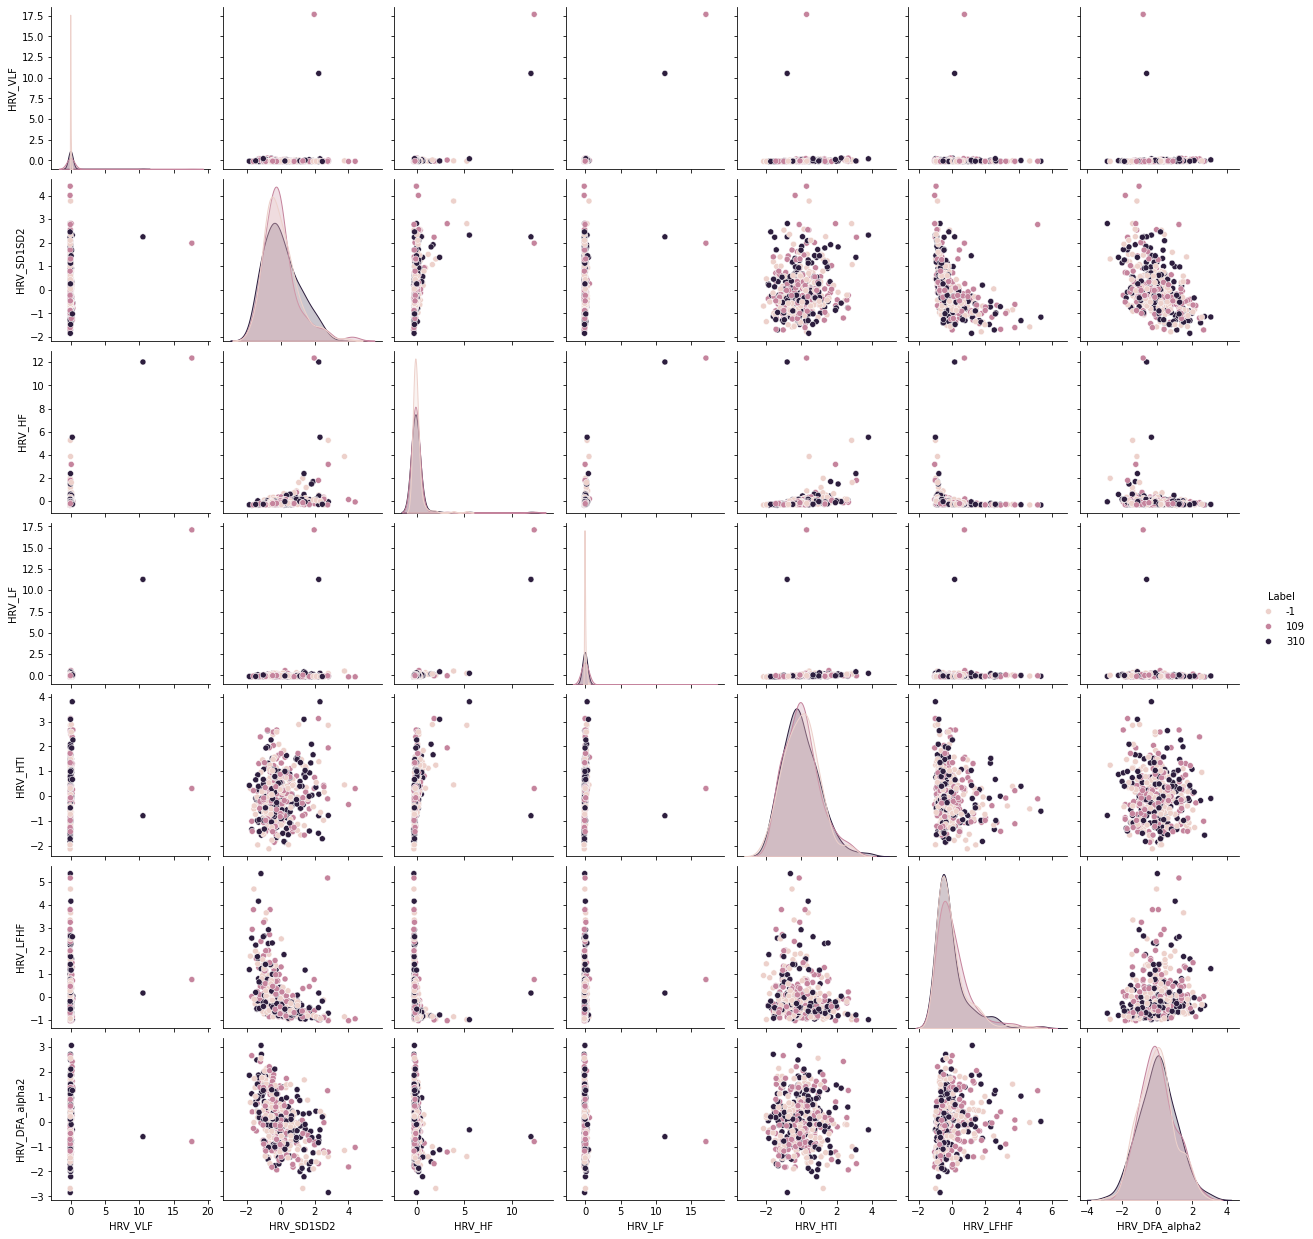

In [ ]:
sns.pairplot(df_new,hue= 'Label',diag_kind='kde')
plt.show()

In [14]:
X_train,X_test,y_train,y_test = train_test_split(df_new,y,test_size=0.25,random_state=42)

Classisfier with confusion matrix

0.27102803738317754


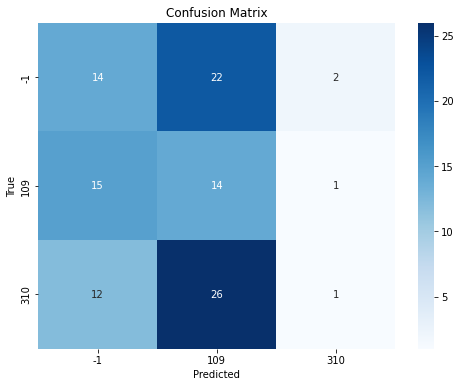

In [16]:
logistic = LogisticRegression()
logistic.fit(X_train,y_train)
y_pred = logistic.predict(X_test)
print(logistic.score(X_test,y_test))

cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

0.2803738317757009


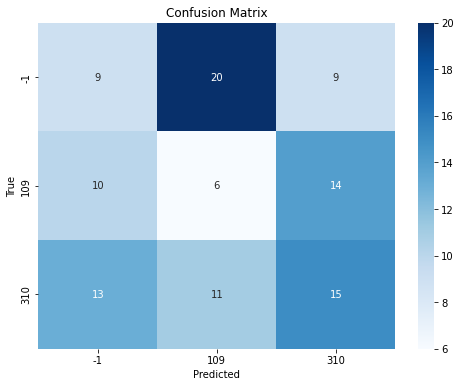

In [17]:
dtree = DecisionTreeClassifier()
dtree.fit(X_train,y_train)
y_pred = dtree.predict(X_test)
print(dtree.score(X_test,y_test))
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

0.3364485981308411


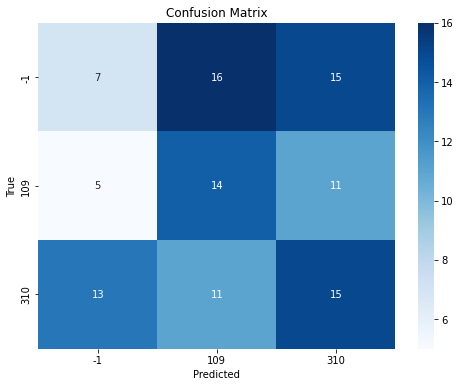

In [18]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print(rf_model.score(X_test,y_test))
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

0.313953488372093


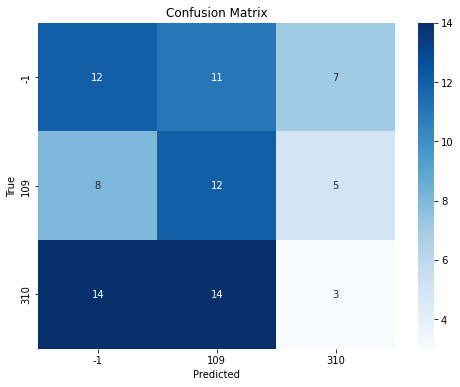

In [ ]:


"""svm_classifier = svm.SVC(kernel='linear', C=1.0, random_state=42)
svm_classifier.fit(X_train,y_train)
y_pred = svm_classifier.predict(X_test)
print(svm_classifier.score(X_test,y_test))
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()"""


0.3023255813953488


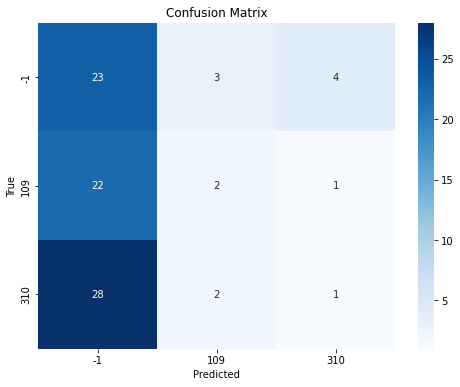

In [ ]:
"""
svm_classifier = svm.SVC(kernel='poly', C=1.0, random_state=42)
svm_classifier.fit(X_train,y_train)
y_pred = svm_classifier.predict(X_test)
print(svm_classifier.score(X_test,y_test))
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()"""


0.2558139534883721


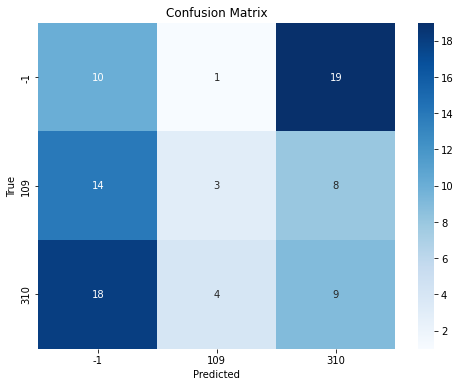

In [ ]:
"""
svm_classifier = svm.SVC(kernel='rbf', C=1.0, random_state=42)
svm_classifier.fit(X_train,y_train)
y_pred = svm_classifier.predict(X_test)
print(svm_classifier.score(X_test,y_test))
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()"""

0.34579439252336447


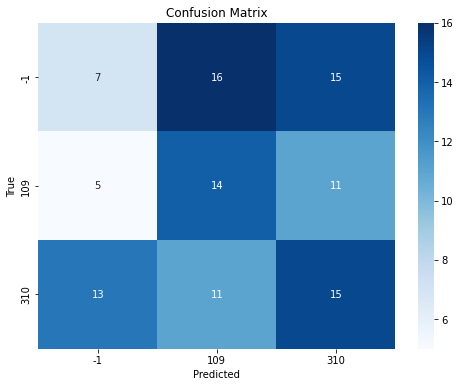

In [19]:

svm_classifier = svm.SVC(kernel='sigmoid', C=1.0, random_state=42)
svm_classifier.fit(X_train,y_train)
svm_classifier.predict(X_test)
print(svm_classifier.score(X_test,y_test))
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()



0.308411214953271


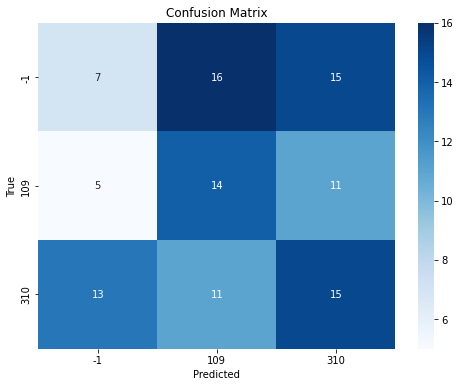

In [20]:
#knn

knn = KNeighborsClassifier()
knn.fit(X_train,y_train)
knn.predict(X_test)
print(knn.score(X_test,y_test))
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

0.3364485981308411


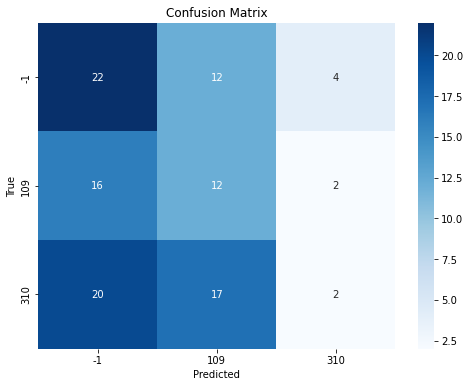

In [21]:
#naive bayes


gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Make predictions on the test set
y_pred = gnb.predict(X_test)
print(gnb.score(X_test,y_test))
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

0.2803738317757009


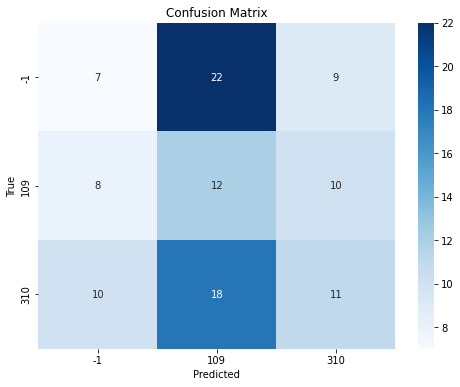

In [22]:


gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbc.fit(X_train, y_train)

# Make predictions on the test set
y_pred = gbc.predict(X_test)
print(gbc.score(X_test,y_test))
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [24]:
# Function to perform cross-validation and return average accuracy
def perform_cross_validation(model, X, y, cv=5):
    cv_scores = cross_val_score(model, X, y, cv=cv)
    
    return cv_scores.mean()

In [25]:
lr_cv_accuracy = perform_cross_validation(logistic, X_test, y_test)
#svm_cv_accuracy = perform_cross_validation(svm, X_test, y_test)
dt_cv_accuracy = perform_cross_validation(dtree, X_test, y_test)
knn_cv_accuracy = perform_cross_validation(knn, X_test, y_test)
nb_cv_accuracy = perform_cross_validation(gnb, X_test, y_test)
gbc_cv_accuracy = perform_cross_validation(gbc, X_test, y_test)
rf_cv_accuracy = perform_cross_validation(rf_model, X_test, y_test)

cv_results = {
    "Logistic Regression": lr_cv_accuracy,
    #"Support Vector Machine": svm_cv_accuracy,
    "Decision Tree": dt_cv_accuracy,
    "K-Nearest Neighbors": knn_cv_accuracy,
    "Naive Bayes": nb_cv_accuracy,
    "Gradient boost": gbc_cv_accuracy,
    "random Forest": rf_cv_accuracy
}

# Convert to percentage format and print
formatted_results = {model: f"{accuracy * 100:.2f}%" for model, accuracy in cv_results.items()}
formatted_results

{'Logistic Regression': '35.37%',
 'Decision Tree': '29.00%',
 'K-Nearest Neighbors': '35.45%',
 'Naive Bayes': '35.41%',
 'Gradient boost': '28.96%',
 'random Forest': '26.10%'}